# Crypto 5분봉 Train - FinRL 튜토리얼
암호화폐 5분봉 데이터를 사용하여 강화학습 에이전트를 학습시킵니다.

원본: Stock NeurIPS2018 Part 2. Train

# Part 1. Install Packages

In [22]:
# 이미 가상환경에 설치되어 있다면 생략 가능
# !pip install stable-baselines3 finrl

In [23]:
import numpy as np
import pandas as pd
from stable_baselines3.common.logger import configure
from stable_baselines3 import A2C, DDPG, PPO, TD3, SAC

from finrl.config import TRAINED_MODEL_DIR, RESULTS_DIR
from finrl.main import check_and_make_directories
from finrl.meta.env_cryptocurrency_trading.env_multiple_crypto import CryptoEnv

check_and_make_directories([TRAINED_MODEL_DIR, RESULTS_DIR])

# Part 2. Build A Market Environment in OpenAI Gym-style

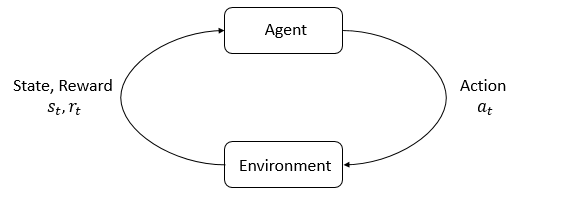

The core element in reinforcement learning are **agent** and **environment**. You can understand RL as the following process: 

The agent is active in a world, which is the environment. It observe its current condition as a **state**, and is allowed to do certain **actions**. After the agent execute an action, it will arrive at a new state. At the same time, the environment will have feedback to the agent called **reward**, a numerical signal that tells how good or bad the new state is. As the figure above, agent and environment will keep doing this interaction.

The goal of agent is to get as much cumulative reward as possible. Reinforcement learning is the method that agent learns to improve its behavior and achieve that goal.

To achieve this in Python, we follow the OpenAI gym style to build the stock data into environment.

state-action-reward are specified as follows:

* **State s**: The state space represents an agent's perception of the market environment. Just like a human trader analyzing various information, here our agent passively observes the price data and technical indicators based on the past data. It will learn by interacting with the market environment (usually by replaying historical data).

* **Action a**: The action space includes allowed actions that an agent can take at each state. For example, a ∈ {−1, 0, 1}, where −1, 0, 1 represent
selling, holding, and buying. When an action operates multiple shares, a ∈{−k, ..., −1, 0, 1, ..., k}, e.g.. "Buy 10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or −10, respectively

* **Reward function r(s, a, s′)**: Reward is an incentive for an agent to learn a better policy. For example, it can be the change of the portfolio value when taking a at state s and arriving at new state s',  i.e., r(s, a, s′) = v′ − v, where v′ and v represent the portfolio values at state s′ and s, respectively


**Market environment**: 30 constituent stocks of Dow Jones Industrial Average (DJIA) index. Accessed at the starting date of the testing period.

## 데이터 로드
Part 1에서 저장한 numpy 배열 데이터를 로드합니다.

In [24]:
# Part 1에서 저장한 데이터 로드
data = np.load('crypto_5m_data.npz', allow_pickle=True)

train_price = data['train_price']
train_tech = data['train_tech']
test_price = data['test_price']
test_tech = data['test_tech']
crypto_pairs = data['crypto_pairs']

print(f"학습 데이터: {len(train_price)} 샘플")
print(f"테스트 데이터: {len(test_price)} 샘플")
print(f"코인 수: {train_price.shape[1]}")
print(f"기술지표 수: {train_tech.shape[1] // train_price.shape[1]}")
print(f"코인 목록: {crypto_pairs}")

학습 데이터: 6823 샘플
테스트 데이터: 1706 샘플
코인 수: 5
기술지표 수: 7
코인 목록: ['BTC/USDT' 'ETH/USDT' 'BNB/USDT' 'XRP/USDT' 'SOL/USDT']


## 암호화폐 트레이딩 환경 구성

CryptoEnv는 다음 정보를 사용합니다:
- **price_array**: 각 시간별 코인 가격
- **tech_array**: 각 시간별 기술적 지표
- **initial_capital**: 초기 자본금
- **buy_cost_pct / sell_cost_pct**: 거래 수수료

In [ ]:
# 환경 설정
crypto_dim = train_price.shape[1]
print(f"코인 수: {crypto_dim}")
print(f"State Dimension: {1 + train_price.shape[1] + train_tech.shape[1]}")
print(f"Action Dimension: {crypto_dim}")

코인 수: 5
State Dimension: 41
Action Dimension: 5


In [26]:
# 학습 환경 생성
train_config = {
    "price_array": train_price,
    "tech_array": train_tech,
}

env_train = CryptoEnv(
    config=train_config,
    lookback=1,
    initial_capital=1_000_000,  # 초기 자본 100만 USDT
    buy_cost_pct=0.001,         # 매수 수수료 0.1%
    sell_cost_pct=0.001,        # 매도 수수료 0.1%
)

print(f"환경 생성 완료!")
print(f"State Dim: {env_train.state_dim}")
print(f"Action Dim: {env_train.action_dim}")
print(f"Max Steps: {env_train.max_step}")

환경 생성 완료!
State Dim: 41
Action Dim: 5
Max Steps: 6821


## Gym Wrapper 생성
Stable Baselines3와 호환되도록 Gym 래퍼를 만듭니다.

In [27]:
import gymnasium as gym
from gymnasium import spaces

class CryptoEnvGym(gym.Env):
    """CryptoEnv를 Gymnasium 인터페이스로 래핑"""
    
    def __init__(self, config, **kwargs):
        super().__init__()
        self.env = CryptoEnv(config, **kwargs)
        
        # Gymnasium spaces 정의
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, 
            shape=(self.env.state_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1, high=1, 
            shape=(self.env.action_dim,), dtype=np.float32
        )
    
    def reset(self, seed=None, options=None):
        state = self.env.reset(seed=seed, options=options)
        return state, {}
    
    def step(self, action):
        state, reward, done, info = self.env.step(action)
        return state, reward, done, False, info or {}

# Gym 환경 생성
env_gym = CryptoEnvGym(
    config=train_config,
    lookback=1,
    initial_capital=1_000_000,
    buy_cost_pct=0.001,
    sell_cost_pct=0.001,
)
print(f"Gym 환경 생성 완료!")
print(f"Observation Space: {env_gym.observation_space}")
print(f"Action Space: {env_gym.action_space}")

Gym 환경 생성 완료!
Observation Space: Box(-inf, inf, (41,), float32)
Action Space: Box(-1.0, 1.0, (5,), float32)


# Part 3: 강화학습 에이전트 학습
Stable Baselines3의 알고리즘들을 사용합니다:
- **A2C**: Advantage Actor-Critic
- **PPO**: Proximal Policy Optimization
- **DDPG**: Deep Deterministic Policy Gradient
- **TD3**: Twin Delayed DDPG
- **SAC**: Soft Actor-Critic

In [28]:
# 학습할 알고리즘 선택 (True/False로 설정)
if_using_a2c = True
if_using_ppo = True
if_using_ddpg = True  # 시간이 오래 걸림
if_using_td3 = True   # 시간이 오래 걸림
if_using_sac = True   # 시간이 오래 걸림

# 학습 스텝 수 (5분봉 데이터는 양이 많으므로 적게 설정)
TOTAL_TIMESTEPS = 10000  # 테스트용, 실제로는 50000 이상 권장

## Agent 1: A2C (Advantage Actor-Critic)

A2C는 Actor-Critic 방법의 동기식 버전으로, 빠르고 안정적인 학습이 가능합니다.

In [29]:
if if_using_a2c:
    # 환경 새로 생성
    env_a2c = CryptoEnvGym(config=train_config, lookback=1, initial_capital=1_000_000)
    
    # A2C 모델 생성
    model_a2c = A2C(
        "MlpPolicy",
        env_a2c,
        verbose=1,
        n_steps=5,
        ent_coef=0.01,
        learning_rate=0.0007,
    )
    
    # 로거 설정
    tmp_path = RESULTS_DIR + '/a2c'
    new_logger_a2c = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    model_a2c.set_logger(new_logger_a2c)
    
    print("A2C 모델 생성 완료!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to results/a2c
A2C 모델 생성 완료!


In [30]:
if if_using_a2c:
    print("A2C 학습 시작...")
    model_a2c.learn(total_timesteps=TOTAL_TIMESTEPS)
    print("A2C 학습 완료!")

A2C 학습 시작...
------------------------------------
| time/                 |          |
|    fps                | 1579     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -7.24    |
|    explained_variance | -72.2    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 0.0273   |
|    std                | 1.03     |
|    value_loss         | 0.00017  |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 1621     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -7.42    |
|    explained_variance | -11.2    |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        |

In [31]:
if if_using_a2c:
    model_a2c.save(TRAINED_MODEL_DIR + "/crypto_a2c")
    print(f"모델 저장: {TRAINED_MODEL_DIR}/crypto_a2c")

모델 저장: trained_models/crypto_a2c


## Agent 2: PPO (Proximal Policy Optimization)

In [32]:
if if_using_ppo:
    env_ppo = CryptoEnvGym(config=train_config, lookback=1, initial_capital=1_000_000)
    
    model_ppo = PPO(
        "MlpPolicy",
        env_ppo,
        verbose=1,
        n_steps=2048,
        ent_coef=0.01,
        learning_rate=0.00025,
        batch_size=128,
    )
    
    tmp_path = RESULTS_DIR + '/ppo'
    new_logger_ppo = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    model_ppo.set_logger(new_logger_ppo)
    print("PPO 모델 생성 완료!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to results/ppo
PPO 모델 생성 완료!


In [33]:
if if_using_ppo:
    print("PPO 학습 시작...")
    model_ppo.learn(total_timesteps=TOTAL_TIMESTEPS)
    print("PPO 학습 완료!")

PPO 학습 시작...
-----------------------------
| time/              |      |
|    fps             | 4021 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 3268        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012386798 |
|    clip_fraction        | 0.156       |
|    clip_range           | 0.2         |
|    entropy_loss         | -7.1        |
|    explained_variance   | 0.843       |
|    learning_rate        | 0.00025     |
|    loss                 | -0.123      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0204     |
|    std                  | 1           |
|    value_loss           | 0.0053      |
---------------------

In [34]:
if if_using_ppo:
    model_ppo.save(TRAINED_MODEL_DIR + "/crypto_ppo")
    print(f"모델 저장: {TRAINED_MODEL_DIR}/crypto_ppo")

모델 저장: trained_models/crypto_ppo


## Agent 3: DDPG (Deep Deterministic Policy Gradient)

In [35]:
if if_using_ddpg:
    env_ddpg = CryptoEnvGym(config=train_config, lookback=1, initial_capital=1_000_000)
    
    model_ddpg = DDPG(
        "MlpPolicy",
        env_ddpg,
        verbose=1,
        batch_size=100,
        buffer_size=1000000,
        learning_rate=0.001,
    )
    
    tmp_path = RESULTS_DIR + '/ddpg'
    new_logger_ddpg = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    model_ddpg.set_logger(new_logger_ddpg)
    print("DDPG 모델 생성 완료!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to results/ddpg
DDPG 모델 생성 완료!


In [36]:
if if_using_ddpg:
    print("DDPG 학습 시작...")
    model_ddpg.learn(total_timesteps=TOTAL_TIMESTEPS)
    model_ddpg.save(TRAINED_MODEL_DIR + "/crypto_ddpg")
    print("DDPG 학습 및 저장 완료!")

DDPG 학습 시작...
DDPG 학습 및 저장 완료!


## Agent 4: TD3 (Twin Delayed DDPG)

In [37]:
if if_using_td3:
    env_td3 = CryptoEnvGym(config=train_config, lookback=1, initial_capital=1_000_000)
    
    model_td3 = TD3(
        "MlpPolicy",
        env_td3,
        verbose=1,
        batch_size=100,
        buffer_size=1000000,
        learning_rate=0.001,
    )
    
    tmp_path = RESULTS_DIR + '/td3'
    new_logger_td3 = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    model_td3.set_logger(new_logger_td3)
    print("TD3 모델 생성 완료!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to results/td3
TD3 모델 생성 완료!


In [38]:
if if_using_td3:
    print("TD3 학습 시작...")
    model_td3.learn(total_timesteps=TOTAL_TIMESTEPS)
    model_td3.save(TRAINED_MODEL_DIR + "/crypto_td3")
    print("TD3 학습 및 저장 완료!")

TD3 학습 시작...
TD3 학습 및 저장 완료!


## Agent 5: SAC (Soft Actor-Critic)

In [39]:
if if_using_sac:
    env_sac = CryptoEnvGym(config=train_config, lookback=1, initial_capital=1_000_000)
    
    model_sac = SAC(
        "MlpPolicy",
        env_sac,
        verbose=1,
        batch_size=128,
        buffer_size=100000,
        learning_rate=0.0001,
        learning_starts=100,
        ent_coef="auto_0.1",
    )
    
    tmp_path = RESULTS_DIR + '/sac'
    new_logger_sac = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    model_sac.set_logger(new_logger_sac)
    print("SAC 모델 생성 완료!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to results/sac
SAC 모델 생성 완료!


In [40]:
if if_using_sac:
    print("SAC 학습 시작...")
    model_sac.learn(total_timesteps=TOTAL_TIMESTEPS)
    model_sac.save(TRAINED_MODEL_DIR + "/crypto_sac")
    print("SAC 학습 및 저장 완료!")

SAC 학습 시작...
SAC 학습 및 저장 완료!


# Part 4: 학습 완료
학습된 모델은 `trained_models/` 디렉토리에 저장됩니다.

In [41]:
# 저장된 모델 확인
import os
print("저장된 모델 목록:")
for f in os.listdir(TRAINED_MODEL_DIR):
    if f.startswith("crypto_"):
        print(f"  - {f}")

저장된 모델 목록:
  - crypto_a2c.zip
  - crypto_ddpg.zip
  - crypto_ppo.zip
  - crypto_sac.zip
  - crypto_td3.zip


## 다음 단계
Part 3 (Backtest) 노트북에서 학습된 모델을 테스트 데이터로 평가합니다.

In [42]:
# 테스트 데이터도 저장해두기 (Part 3에서 사용)
np.savez(
    'crypto_test_data.npz',
    test_price=test_price,
    test_tech=test_tech,
    crypto_pairs=crypto_pairs,
)
print("테스트 데이터 저장 완료: crypto_test_data.npz")

테스트 데이터 저장 완료: crypto_test_data.npz
